In [28]:
import numpy as np
import sklearn as sk
import matplotlib
import matplotlib.pyplot as plt
import scipy.stats
from sklearn.linear_model import LogisticRegression
import pandas as pd

In [29]:
import warnings
warnings.filterwarnings("ignore")

In [30]:
#Set the default figure size for the notebook, so they are not all tiny
matplotlib.rcParams['figure.figsize'] = (12,8)

In [31]:
import rpy2
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [32]:
%%R -o spam

library(ElemStatLearn)
colnames(spam)[1:57] <- c("word_freq_make", "word_freq_address", "word_freq_all", "word_freq_3d", "word_freq_our", "word_freq_over", "word_freq_remove", "word_freq_internet", "word_freq_order", "word_freq_mail", "word_freq_receive", "word_freq_will", "word_freq_people", "word_freq_report", "word_freq_addresses", "word_freq_free", "word_freq_business", "word_freq_email", "word_freq_you", "word_freq_credit", "word_freq_your", "word_freq_font", "word_freq_000", "word_freq_money", "word_freq_hp", "word_freq_hpl", "word_freq_george", "word_freq_650", "word_freq_lab", "word_freq_labs", "word_freq_telnet", "word_freq_857", "word_freq_data", "word_freq_415", "word_freq_85", "word_freq_technology", "word_freq_1999", "word_freq_parts", "word_freq_pm", "word_freq_direct", "word_freq_cs", "word_freq_meeting", "word_freq_original", "word_freq_project", "word_freq_re", "word_freq_edu", "word_freq_table", "word_freq_conference", "char_freq_semicol", "char_freq_paren", "char_freq_bracket", "char_freq_exc", "char_freq_dollar", "char_freq_pound", "capital_run_length_average", "capital_run_length_longest", "capital_run_length_total")


In [33]:
print(spam.shape)
spam.head()

(4601, 58)


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_semicol,char_freq_paren,char_freq_bracket,char_freq_exc,char_freq_dollar,char_freq_pound,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,spam
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,spam
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,spam
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,spam
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,spam


In [34]:
X = spam.iloc[:,0:57]
y = np.where(spam['spam']=='spam',1,0)

In [35]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=1)

In [36]:
#The sklearn version of logistic regression automatically has a ridge penalty
#Large C means small penalty here (opposite of lambda)
lmfit = LogisticRegression(C=1000000).fit(X_train, y_train)

yhat_lm = lmfit.predict(X_test)
np.mean(y_test!=yhat_lm)


0.07636603028308098

In [10]:
from sklearn.linear_model import LogisticRegressionCV
lassofit = LogisticRegressionCV(penalty='l1', solver='liblinear', Cs=50).fit(X_train, y_train)
yhat_lasso = lassofit.predict(X_test)
np.mean(y_test!=yhat_lasso)


0.07307439104674128

How about trees?

In [37]:
from sklearn.tree import DecisionTreeClassifier
treefit = DecisionTreeClassifier(min_samples_leaf=200).fit(X_train,y_train)
yhat_tree = treefit.predict(X_test)
np.mean(yhat_tree != y_test)

0.14351547070441079

In [38]:
import graphviz
from sklearn.tree import export_graphviz

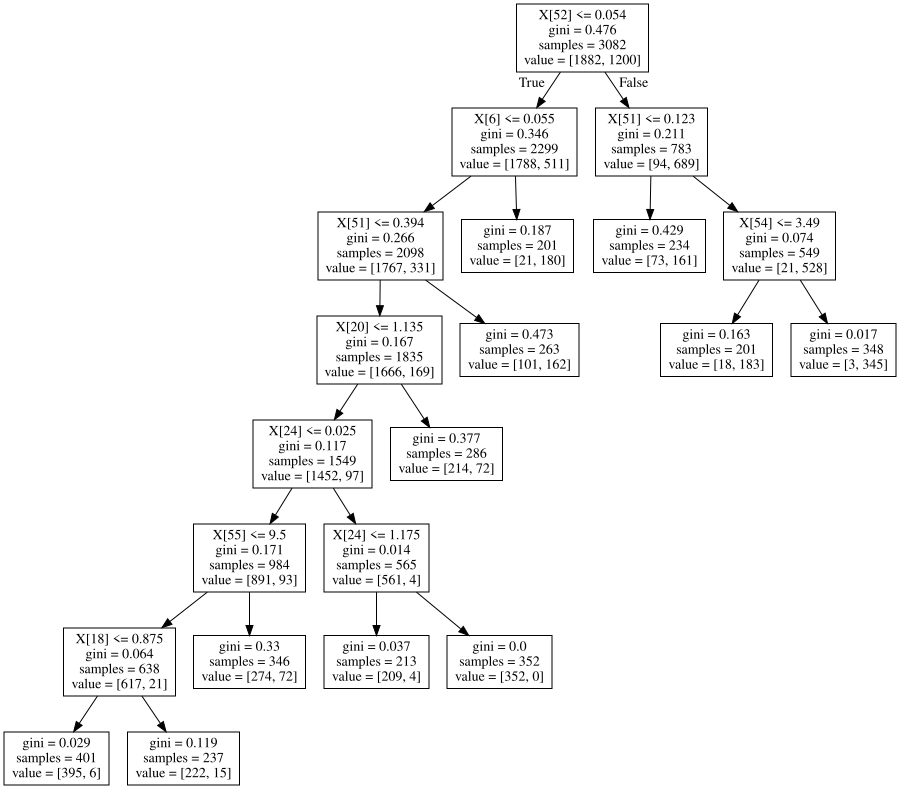

In [39]:
dot_data = export_graphviz(treefit, out_file=None)
graph = graphviz.Source(dot_data)
graph

# What happens if we do pruning in R?

[1] 0.1079658


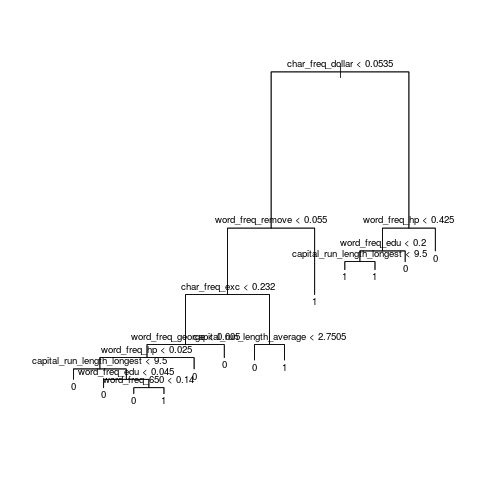

In [40]:
%%R -i X_train -i X_test -i y_train -i y_test

library(tree)
dat_train = cbind(as.factor(y_train),X_train)
dat_test = cbind(as.factor(y_test),X_test)
names(dat_train)[1] = 'y'
names(dat_test)[1] = 'y'

fit.tree = tree(y~., data=dat_train)

yhat1 = predict(fit.tree, dat_test, type='class')
print(mean(yhat1 != y_test))

plot(fit.tree)
text(fit.tree, pretty=0, cex=0.8)


$size
[1] 13 12  7  6  5  3  2  1

$dev
[1]  331  330  326  336  394  457  610 1200

$k
[1]  -Inf   0.0   1.2  14.0  36.0  51.0 159.0 595.0

$method
[1] "misclass"

attr(,"class")
[1] "prune"         "tree.sequence"


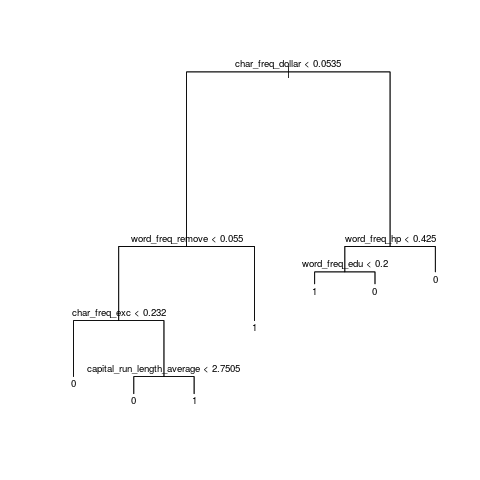

In [41]:
%%R

set.seed(3)

fit.tree.cv = cv.tree(fit.tree, FUN=prune.misclass)
print(fit.tree.cv)

fit.tree.pruned = prune.misclass(fit.tree, best=fit.tree.cv$size[which.min(fit.tree.cv$dev)])
plot(fit.tree.pruned)
text(fit.tree.pruned, pretty=0, cex=0.8)

In [42]:
%%R

yhat2 = predict(fit.tree.pruned, dat_test, type='class')
print(mean(yhat2 != y_test))

[1] 0.1105991


# Finally, let's look at random forests

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
fitrf = RandomForestClassifier(n_estimators=500, oob_score=True, random_state=1).fit(X_train, y_train)

In [45]:
yhat_rf = fitrf.predict(X_test)
np.mean(yhat_rf != y_test)

0.040157998683344305

In [46]:
1-fitrf.oob_score_

0.053212199870214194

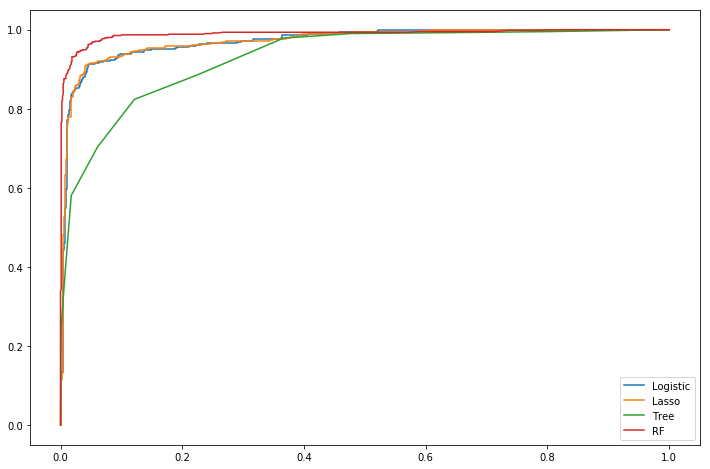

In [21]:
from sklearn.metrics import roc_curve

roc_logit = roc_curve(y_test,  lmfit.predict_proba(X_test)[:,1])
roc_lasso = roc_curve(y_test, lassofit.predict_proba(X_test)[:,1])
roc_tree = roc_curve(y_test, treefit.predict_proba(X_test)[:,1])
roc_rf = roc_curve(y_test, fitrf.predict_proba(X_test)[:,1])

line1, = plt.plot(roc_logit[0],roc_logit[1])
line2, = plt.plot(roc_lasso[0],roc_lasso[1])
line3, = plt.plot(roc_tree[0],roc_tree[1])
line4, = plt.plot(roc_rf[0],roc_rf[1])

plt.legend((line1,line2,line3,line4), ('Logistic','Lasso','Tree','RF'))
plt.show()

## How does it work?

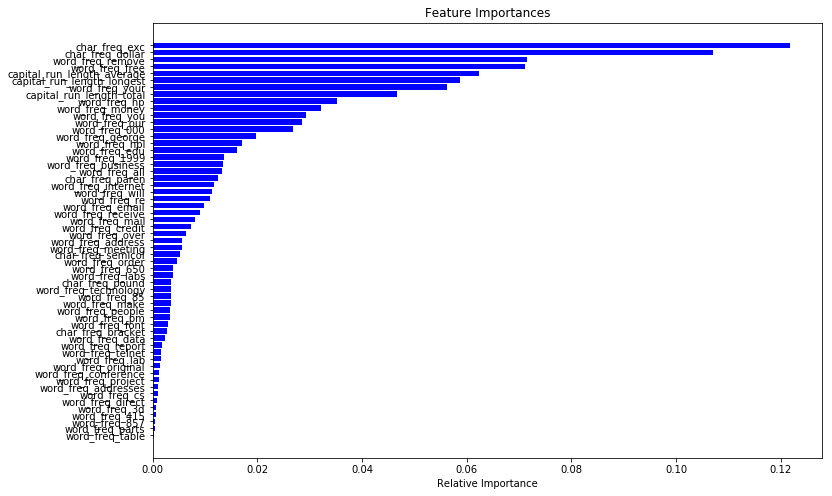

In [47]:
#Nice plotting approach from
#https://stackoverflow.com/questions/44101458/random-forest-feature-importance-chart-using-python
features = spam.columns
importances = fitrf.feature_importances_
indices = np.argsort(importances)

plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

# Now we switch to R

In [48]:
%%R -i X_train -i X_test -i y_train -i y_test

library(randomForest)

fitrf = randomForest(X_train, as.factor(y_train))
fitrf


Call:
 randomForest(x = X_train, y = as.factor(y_train)) 
               Type of random forest: classification
                     Number of trees: 500
No. of variables tried at each split: 7

        OOB estimate of  error rate: 5.03%
Confusion matrix:
     0    1 class.error
0 1822   60  0.03188098
1   95 1105  0.07916667


In [24]:
%%R
mean(predict(fitrf, X_test)!= y_test)

[1] 0.04476629


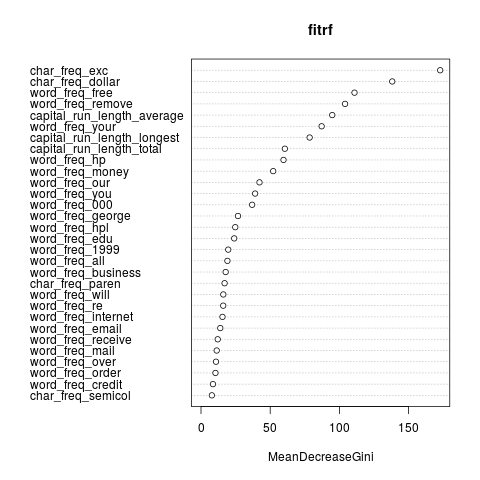

In [25]:
%%R
varImpPlot(fitrf)

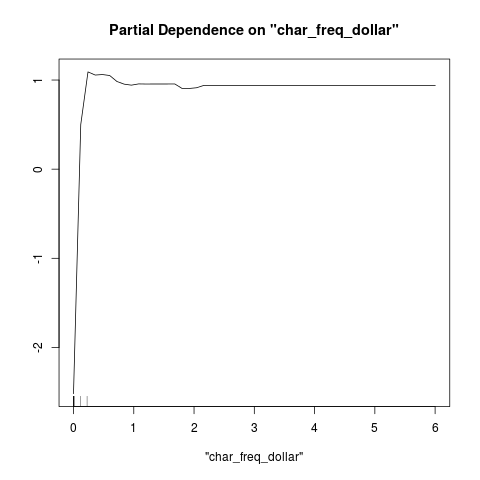

In [26]:
%%R
partialPlot(fitrf, X_train, x.var='char_freq_dollar', which.class=1)

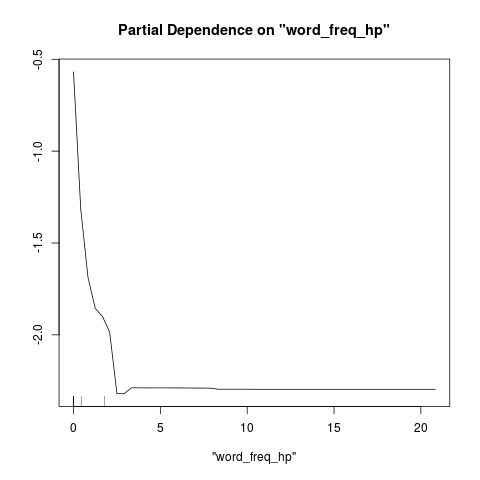

In [27]:
%%R
partialPlot(fitrf, X_train, x.var='word_freq_hp', which.class=1)